In [ ]:
from time import time  # importing time module for measuring execution time
import numpy as np  # importing numpy for numerical operations
import matplotlib.pyplot as plt  # importing matplotlib for visualization
from sklearn.ensemble import RandomForestClassifier  # importing random forest classifier for classification
from sklearn.model_selection import train_test_split  # importing function to split dataset into training and testing
from sklearn.metrics import roc_auc_score  # importing roc auc score metric to evaluate model performance
import skimage as ski  # importing skimage for image processing tasks

In [ ]:
def extract_feature_image(img, feature_type, feature_coord=None):
    """extracts the haar-like feature for the given image"""
    ii = ski.transform.integral_image(img)  # compute the integral image of the input image
    # extract haar-like features using the integral image
    return ski.feature.haar_like_feature(
        ii,  # integral image
        0,  # starting x-coordinate
        0,  # starting y-coordinate
        ii.shape[0],  # height of the region
        ii.shape[1],  # width of the region
        feature_type=feature_type,  # type of haar-like feature
        feature_coord=feature_coord,  # specific feature coordinates (optional)
    )


In [ ]:
images = ski.data.lfw_subset()  # load a subset of the LFW (Labeled Faces in the Wild) dataset

# to speed up computation, extract only two types of haar-like features
feature_types = ['type-2-x', 'type-2-y']

# compute haar-like features for all images
t_start = time()  # start timing
X = [extract_feature_image(img, feature_types) for img in images]  # extract features for each image
X = np.stack(X)  # stack extracted features into a NumPy array
time_full_feature_comp = time() - t_start  # compute total feature extraction time

# create labels for the dataset (100 faces labeled as 1, 100 non-faces labeled as 0)
y = np.array([1] * 100 + [0] * 100)

# split the dataset into training (150 samples) and testing (50 samples) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=150, random_state=0, stratify=y
)

# extract all possible feature coordinates for the given image dimensions
feature_coord, feature_type = ski.feature.haar_like_feature_coord(
    width=images.shape[2],  # width of images
    height=images.shape[1],  # height of images
    feature_type=feature_types  # types of haar-like features to extract
)


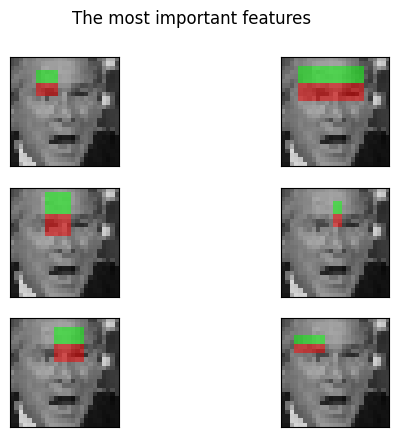

In [ ]:
# train a random forest classifier and assess its performance
clf = RandomForestClassifier(
    n_estimators=1000,  # number of trees in the forest
    max_depth=None,  # no limit on tree depth
    max_features=100,  # number of features considered for splitting at each node
    n_jobs=-1,  # use all available CPU cores for parallel processing
    random_state=0  # ensure reproducibility
)

# measure training time
t_start = time()
clf.fit(X_train, y_train)  # train the classifier
time_full_train = time() - t_start  # compute total training time

# evaluate model performance using the area under the ROC curve (AUC)
auc_full_features = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])

# sort features based on their importance (descending order)
idx_sorted = np.argsort(clf.feature_importances_)[::-1]

# plot the six most significant haar-like features
fig, axes = plt.subplots(3, 2)  # create a 3x2 grid for visualization
for idx, ax in enumerate(axes.ravel()):  # iterate over six subplots
    image = images[0]  # select a sample image
    image = ski.feature.draw_haar_like_feature(
        image,  # input image
        0, 0,  # feature starting coordinates (top-left corner)
        images.shape[2],  # width of the image
        images.shape[1],  # height of the image
        [feature_coord[idx_sorted[idx]]]  # select the most important feature
    )
    ax.imshow(image)  # display the feature visualization
    ax.set_xticks([])  # remove x-axis ticks
    ax.set_yticks([])  # remove y-axis ticks

_ = fig.suptitle('The most important features')  # set the figure title


In [ ]:
# compute the cumulative sum of feature importances in descending order
cdf_feature_importances = np.cumsum(clf.feature_importances_[idx_sorted])

# normalize by the maximum value to get a cumulative distribution
cdf_feature_importances /= cdf_feature_importances[-1]

# determine the number of most significant features contributing to 70% of importance
sig_feature_count = np.count_nonzero(cdf_feature_importances < 0.7)

# calculate the percentage of these significant features
sig_feature_percent = round(sig_feature_count / len(cdf_feature_importances) * 100, 1)

# print the number and percentage of most informative features
print(
    f'{sig_feature_count} features, or {sig_feature_percent}%, '
    f'account for 70% of branch points in the random forest.'
)

# select the most informative feature coordinates based on their importance
feature_coord_sel = feature_coord[idx_sorted[:sig_feature_count]]
feature_type_sel = feature_type[idx_sorted[:sig_feature_count]]

# note: instead of selecting features directly from the feature matrix X,
# we recompute the features using `feature_coord` and `feature_type` for flexibility.

# compute the subset of selected features
t_start = time()
X = [extract_feature_image(img, feature_type_sel, feature_coord_sel) for img in images]  # extract only significant features
X = np.stack(X)  # stack extracted features into a NumPy array
time_subs_feature_comp = time() - t_start  # compute the feature extraction time

# create labels for the dataset (100 faces labeled as 1, 100 non-faces labeled as 0)
y = np.array([1] * 100 + [0] * 100)

# split the dataset into training (150 samples) and testing (50 samples) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=150, random_state=0, stratify=y
)

712 features, or 0.7%, account for 70% of branch points in the random forest.


In [ ]:
# record the start time for training on the reduced feature set
t_start = time()

# train the random forest classifier using the selected subset of features
clf.fit(X_train, y_train)

# compute the training time for the subset of features
time_subs_train = time() - t_start

# calculate the AUC score for the model trained with the reduced feature set
auc_subs_features = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])

# generate a summary comparing full vs. reduced feature set computation and training time
summary = (
    f'Computing the full feature set took '
    f'{time_full_feature_comp:.3f}s, '  # time taken to compute all features
    f'plus {time_full_train:.3f}s training, '  # training time for full features
    f'for an AUC of {auc_full_features:.2f}. '  # AUC score for full feature model
    f'Computing the restricted feature set took '
    f'{time_subs_feature_comp:.3f}s, plus {time_subs_train:.3f}s '  # feature extraction and training time for reduced features
    f'training, for an AUC of {auc_subs_features:.2f}.'  # AUC score for reduced feature model
)

# print the summary of performance and efficiency
print(summary)

# display any pending plots
plt.show()

Computing the full feature set took 54.122s, plus 6.235s training, for an AUC of 1.00. Computing the restricted feature set took 0.219s, plus 4.253s training, for an AUC of 1.00.
